In [2]:
%matplotlib widget
from lines import REDUC_LINES
from corr import REDSHIFT, SPECTRALDATA
from new_lines import fitting_lines, a_ratio_dist, save_data, fit_auroral_new, save_data_auroral_MC

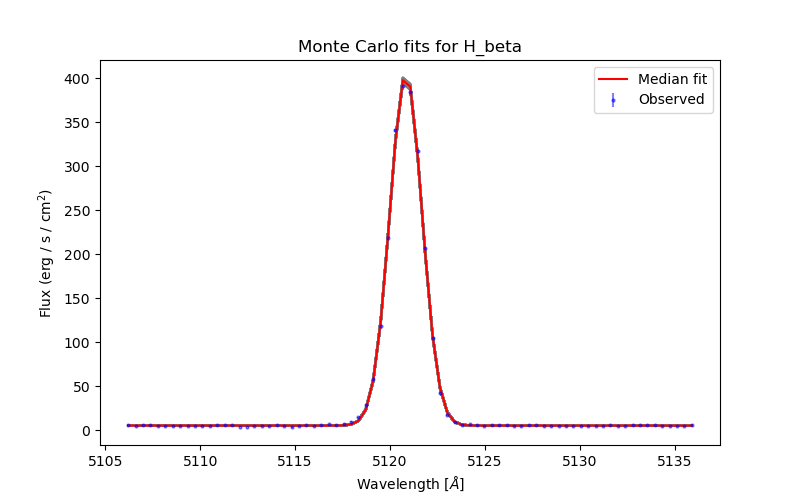

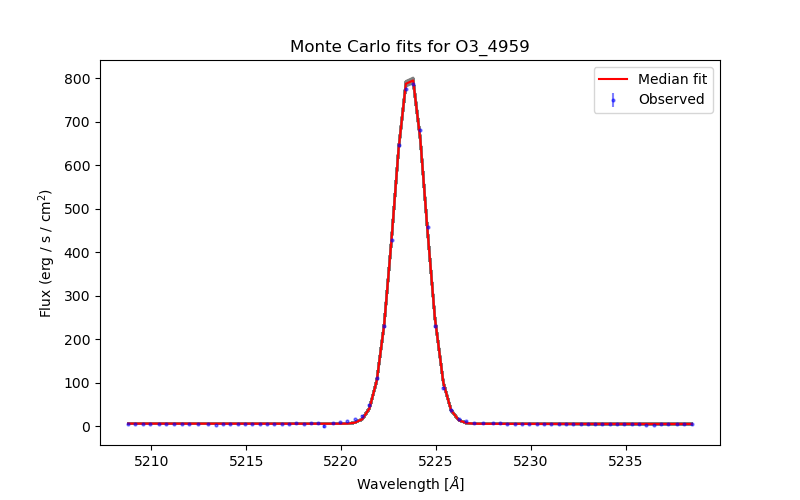

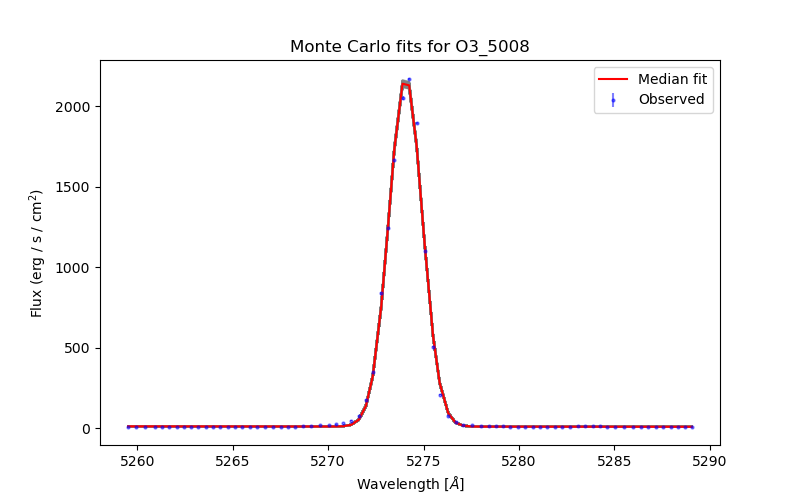

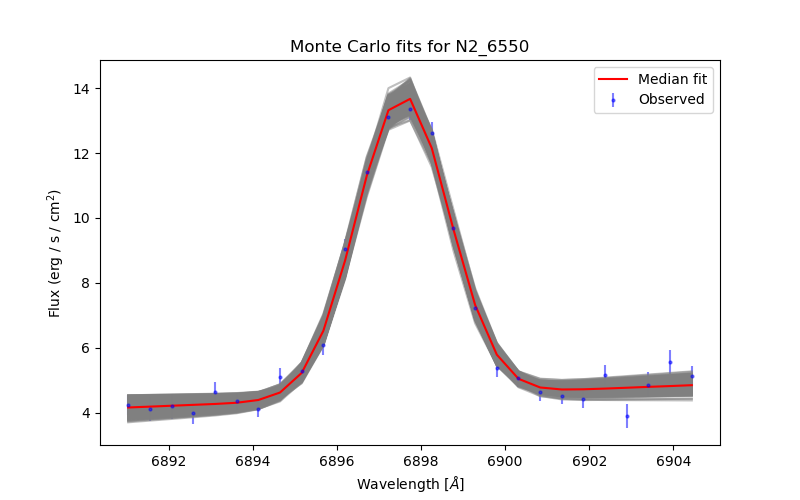

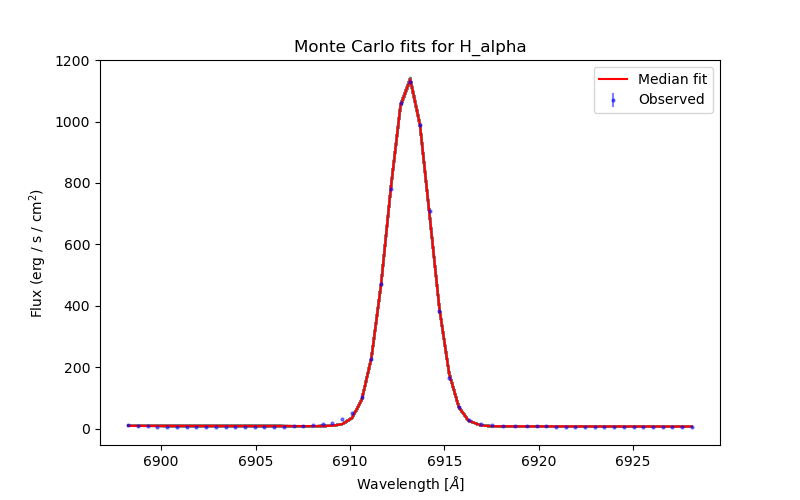

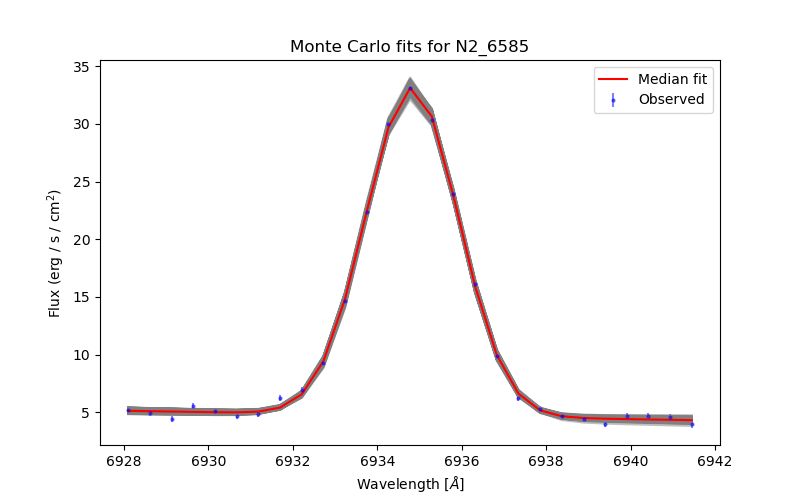

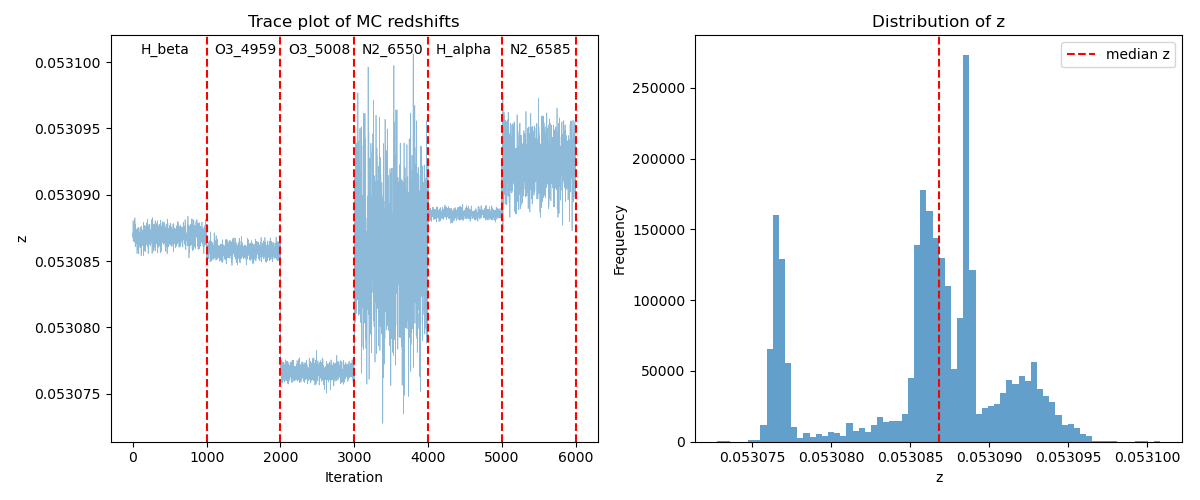

New redshift calculated for J0023.fits,z = 0.0530868339472681
Executed reset_redshift in 45.5775s
New redshift for J0023-0948,z = 0.0530868339472681


In [3]:
J0023_ = {'DIR':'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/',
         'FILES': ['J0023.fits'],
         'redshift':0.05337,
         'names':['J0023-0948'],
         'mass':8.9}

J0023 = SPECTRALDATA(J0023_)
Z = REDSHIFT(J0023)

Reading data for J0023
Using uncorrected data


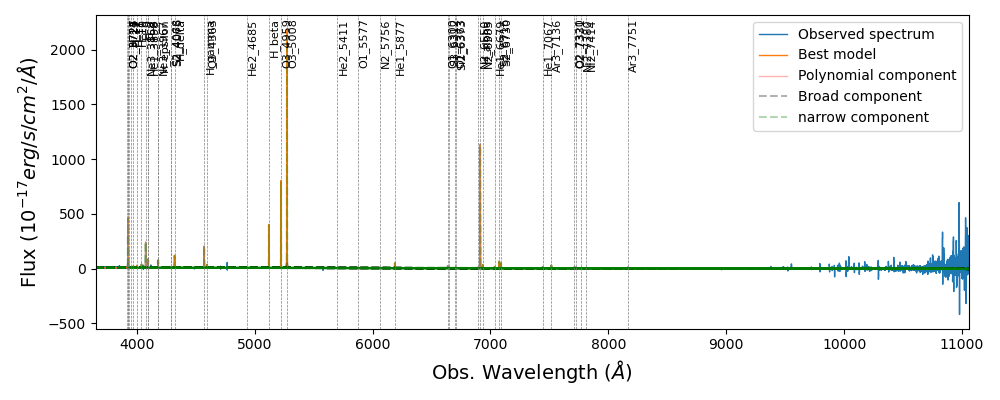

In [4]:
red = REDUC_LINES(J0023)
fit = red.fit_spectra(show_Plot=True)

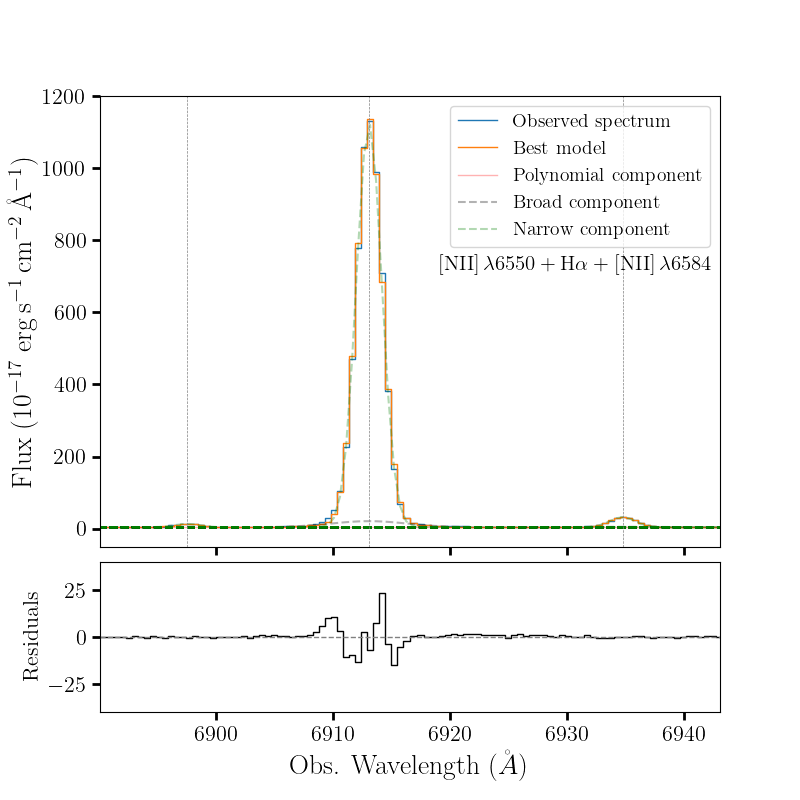

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

fig2, (ax, ax_res) = plt.subplots(
    2, 1, figsize=(8, 8),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}
)

comps = fit.eval_components(x=red.wave)

# --- Main spectrum ---
narrow_key = [key for key, _ in comps.items() if 'narrow' in key]

ax.plot(red.wave, red.flux, lw=1, drawstyle='steps-mid',
        label='Observed spectrum')

ax.plot(red.wave, fit.best_fit, lw=1, drawstyle='steps-mid',
        label='Best model')

ax.plot(red.wave, comps['polynomial'], 'r-',
        label='Polynomial component',
        lw=1, drawstyle='steps-mid', alpha=0.3)

broad_key = [key for key, _ in comps.items() if 'broad' in key]

for i, broad_line in enumerate(broad_key):
    ax.plot(red.wave, comps[broad_line] + comps['polynomial'],
            'k--',
            label='Broad component' if i == len(broad_key)-1 else None,
            alpha=0.3)

for i, narrow_line in enumerate(narrow_key):
    ax.plot(red.wave, comps[narrow_line] + comps['polynomial'],
            'g--',
            label='Narrow component' if i == len(narrow_key)-1 else None,
            alpha=0.3)


# --- Residuals ---
residuals = red.flux - fit.best_fit

ax_res.plot(red.wave, residuals,
            color='black',
            lw=1,
            drawstyle='steps-mid')

ax_res.axhline(0, color='grey', linestyle='--', lw=1)

ax_res.set_ylabel('Residuals', size=16)
ax_res.set_xlabel(r'Obs. Wavelength ($\AA$)', size=20)
ax_res.set_ylim(-40, 40)


# --- Emission line markers ---
for label in red.spectra.linelist_dict.keys():
    obs_lam = red.spectra.linelist_dict[label] * (1 + red.spectra.redshift)

    ax.axvline(obs_lam, linestyle='--',
               linewidth=0.5, color='grey')


ax.text(0.99, 0.65,
    r'$[\mathrm{NII}]\,\lambda6550 + \mathrm{H\alpha} +[\mathrm{NII}]\,\lambda6584$',
    transform=ax.transAxes,
    fontsize=15,
    color='k',
    ha='right',
    va='top'
)
# --- Formatting ---
ax.set_ylabel(r'Flux ($10^{-17}\ \mathrm{erg\,s^{-1}\,cm^{-2}\,\AA^{-1}}$)', size=20)
obs_lam = red.spectra.linelist_dict['H_alpha'] * (1 + red.spectra.redshift)
ax.set_xlim(obs_lam-23, obs_lam+30)
ax.set_ylim(-50, 1200)

ax.legend(fontsize=14, frameon=True, loc='upper right')
ax_res.tick_params(
    axis='both',
    which='major',
    labelsize=16,
    width=2,
    length=6
)
ax.tick_params(
    axis='both',
    which='major',
    labelsize=16,
    width=2,
    length=6, labelbottom=False
)


plt.show()

Reading data for J0023
Using MW dust + Balmer abs corrected and continuum substracted data


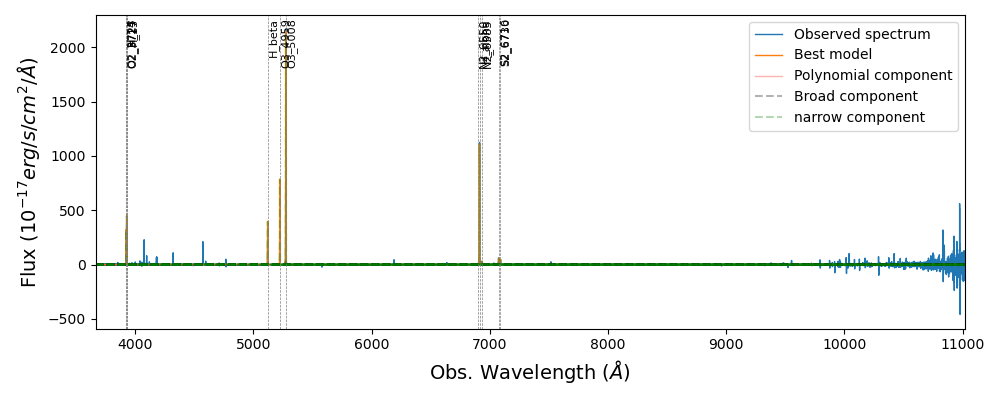

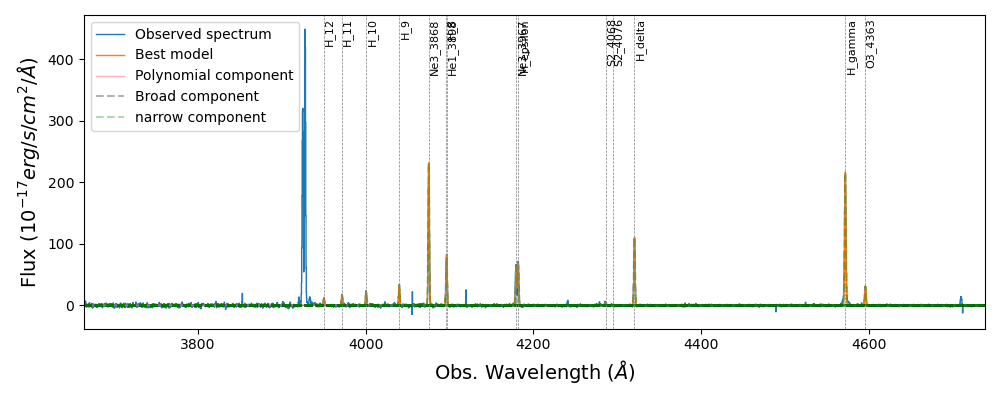

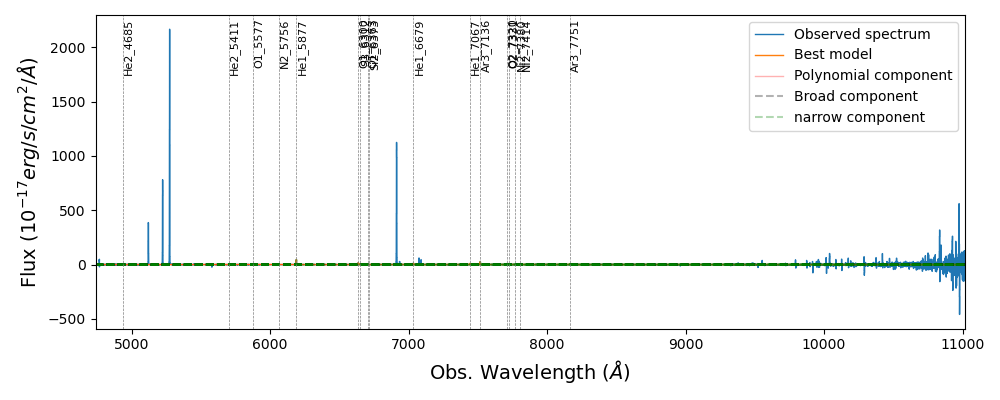

In [3]:
red = REDUC_LINES(J0023)
linelist = red.spectra.linelist_dict
bright_lines = ['H_14', 'H_13', 'O2_3725', 'O2_3727', 'H_alpha', 'H_beta',
                'O3_5008', 'O3_4959', 'N2_6550', 'N2_6585',
                'S2_6716','S2_6730']

bright_dict = {k: v for k, v in linelist.items() if k in bright_lines}
faint_dict  = {k: v for k, v in linelist.items() if k not in bright_lines}

mask = (red.wave < 4500*(1+red.spectra.redshift))
wave1, flux1, sigma1 = red.wave[mask], red.flux[mask], red.sigma[mask]
wave2, flux2, sigma2 = red.wave[~mask], red.flux[~mask], red.sigma[~mask]

blue_lines_b = {k:v for k,v in bright_dict.items() if v < 4500}
red_lines_b  = {k:v for k,v in bright_dict.items() if v >= 4500}

blue_lines_f = {k:v for k,v in faint_dict.items() if v < 4500}
red_lines_f  = {k:v for k,v in faint_dict.items() if v >= 4500}

lines = red.spectra.linelist_dict
blue_lines = {k:v for k,v in lines.items() if v < 4500}
red_lines = {k:v for k,v in lines.items() if v >= 4500}


init = fitting_lines(red.wave, red.flux,
                    bright_dict,
                    z_init=red.spectra.redshift, plot=True,
                    nfev=1000, fit=None, A_ratio=None)
ratios = a_ratio_dist(init, plot=True)
out_blue = fitting_lines(wave1, flux1,
                    blue_lines_f,
                    z_init=red.spectra.redshift, plot=True,
                    nfev=1000, fit=init, A_ratio=ratios)

out_red = fitting_lines(wave2, flux2,
                    red_lines_f,
                    z_init=red.spectra.redshift,plot=True,
                    nfev=1000, fit=init, A_ratio=ratios)

In [4]:
save_data(red, 100)

Starting MC iteration
Saving in /Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/J0023/


,ID,mass,z_red,z_blue,name,flux,fluxerr,narrow_flux,narrow_fluxerr,broad_flux,broad_fluxerr
0,J0023-0948,8.9,0.053081,0.05306,H_14,18.769557,1.079189,18.769557,1.078604,2.199837e-05,0.026531
1,J0023-0948,8.9,0.053081,0.05306,O2_3725,543.114185,4.957113,536.258947,6.792099,5.713758e+00,8.611066
2,J0023-0948,8.9,0.053081,0.05306,O2_3727,744.134356,3.109997,743.532260,3.780675,1.161673e-07,2.890343
3,J0023-0948,8.9,0.053081,0.05306,H_13,43.195850,8.261109,15.005245,5.522719,2.907657e+01,4.817263
4,J0023-0948,8.9,0.053081,0.05306,H_12,19.395480,1.079623,19.395480,1.079623,0.000000e+00,0.000000
5,J0023-0948,8.9,0.053081,0.05306,H_11,28.433556,1.035270,28.433556,1.035270,0.000000e+00,0.000000
6,J0023-0948,8.9,0.053081,0.05306,H_10,37.612584,1.236247,37.612584,1.236247,0.000000e+00,0.000000
7,J0023-0948,8.9,0.053081,0.05306,H_9,53.840999,1.114008,53.840999,1.114008,0.000000e+00,0.000000
8,J0023-0948,8.9,0.053081,0.05306,Ne3_3868,388.000265,2.048974,388.000265,2.048974,0.000000e+00,0.000000
9,J0023-0948,8.9,0.053081,0.05306,He1_3898,131.346620,1.659995,131.346620,1.659995,0.000000e+00,0.000000


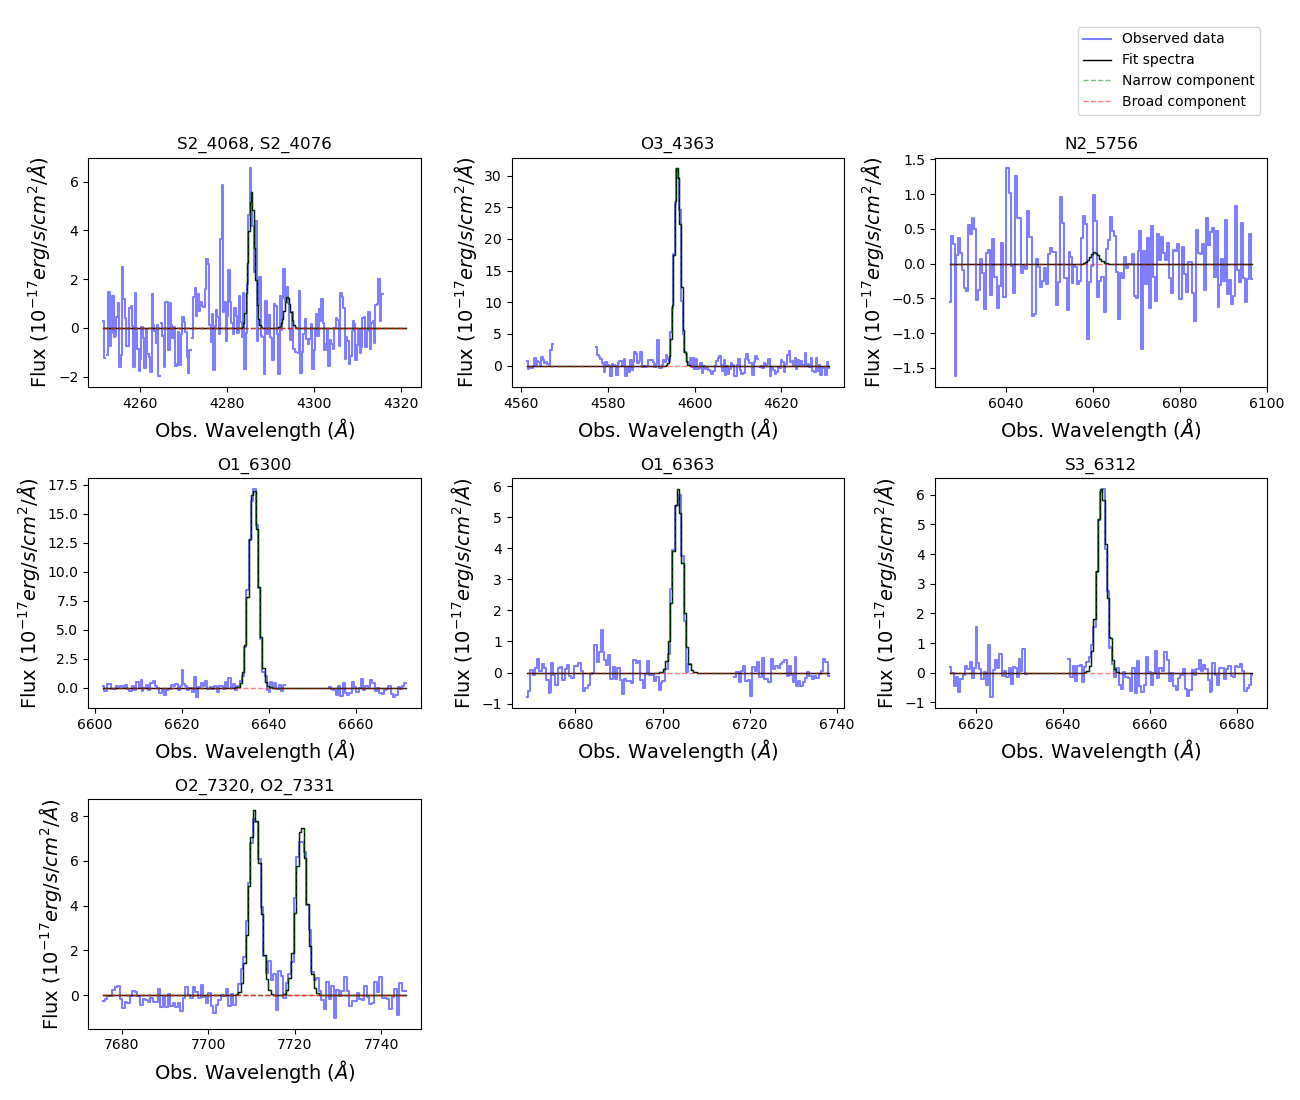

/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/new_lines.py:543: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comps.append(fit)


In [5]:
a, b = fit_auroral_new(red, ratio=ratios, flux_=red.flux, showplot=True)
info, res = save_data_auroral_MC(red, ratio=ratios, num=100)

Reading data for J0023
Using uncorrected data
Performing Balmer absorption correction for J0023
Using uncorrected data


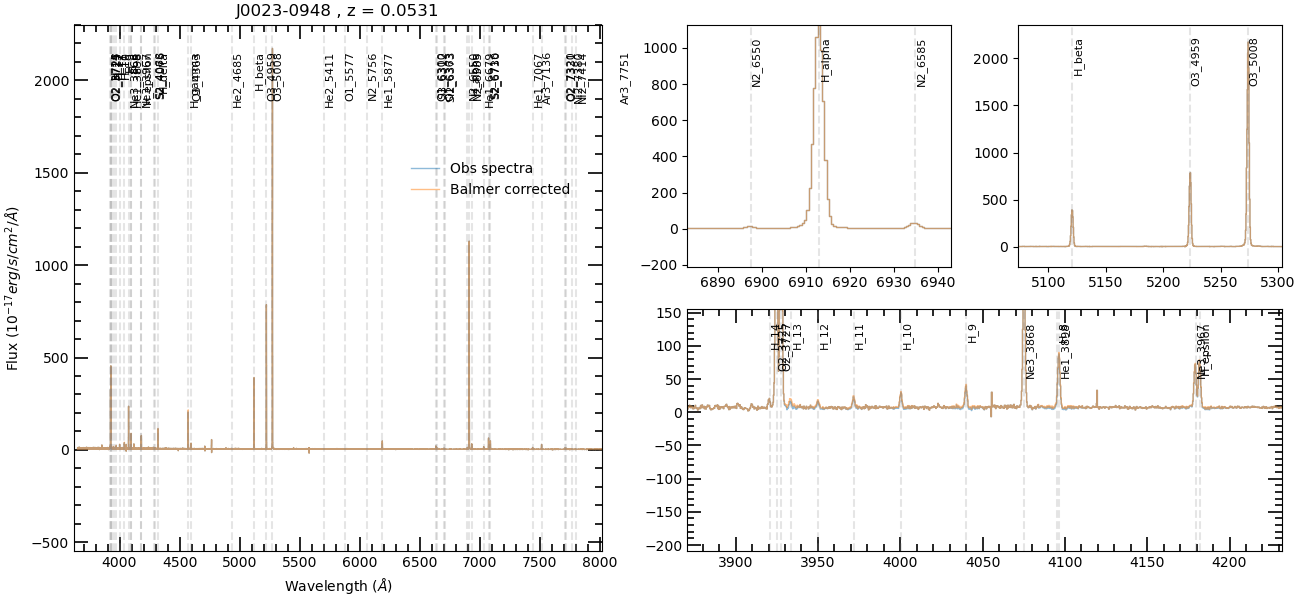

Saved Balmer Absorption corrected data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/bal_abs/bcorr_J0023.csv
Balmer absorption correction done!
Executed bal_abs_corr in 13.2219s


In [5]:
b = BALMER_ABS(J0023)

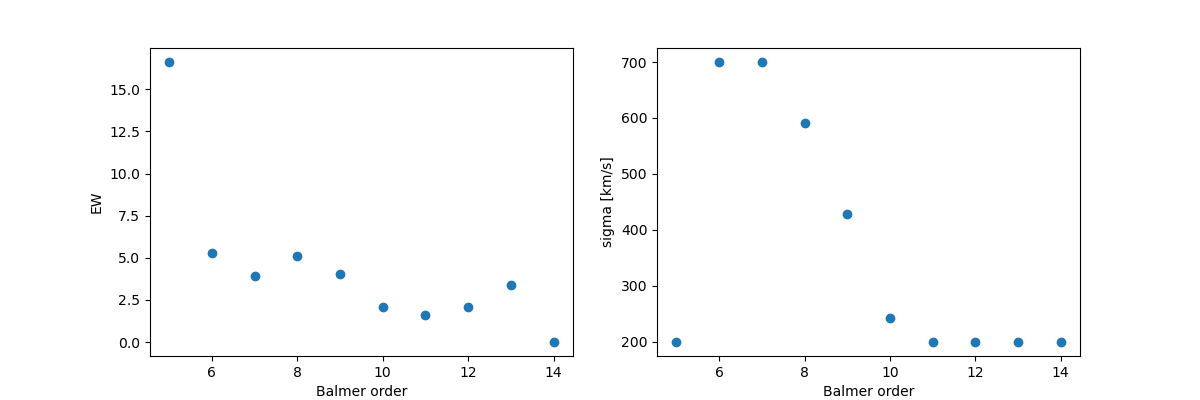

,ID,z,name,sigma,EW
0,J0023-0948,0.053086,H_beta,700.000000,-2.369905
1,J0023-0948,0.053086,H_gamma,200.000000,-16.626930
2,J0023-0948,0.053086,H_delta,700.000000,-5.270594
3,J0023-0948,0.053086,H_epsilon,700.000000,-3.900523
4,J0023-0948,0.053086,H_8,591.039117,-5.082063
5,J0023-0948,0.053086,H_9,428.473926,-4.058948
6,J0023-0948,0.053086,H_10,243.000641,-2.088947
7,J0023-0948,0.053086,H_11,200.000225,-1.628381
8,J0023-0948,0.053086,H_12,199.999776,-2.102488
9,J0023-0948,0.053086,H_13,199.999813,-3.356938


In [105]:
b.EW()

Reading data for J0023
Using MW dust + Balmer abs corrected  data
Executed cont_est in 0.1617s
Using uncorrected data


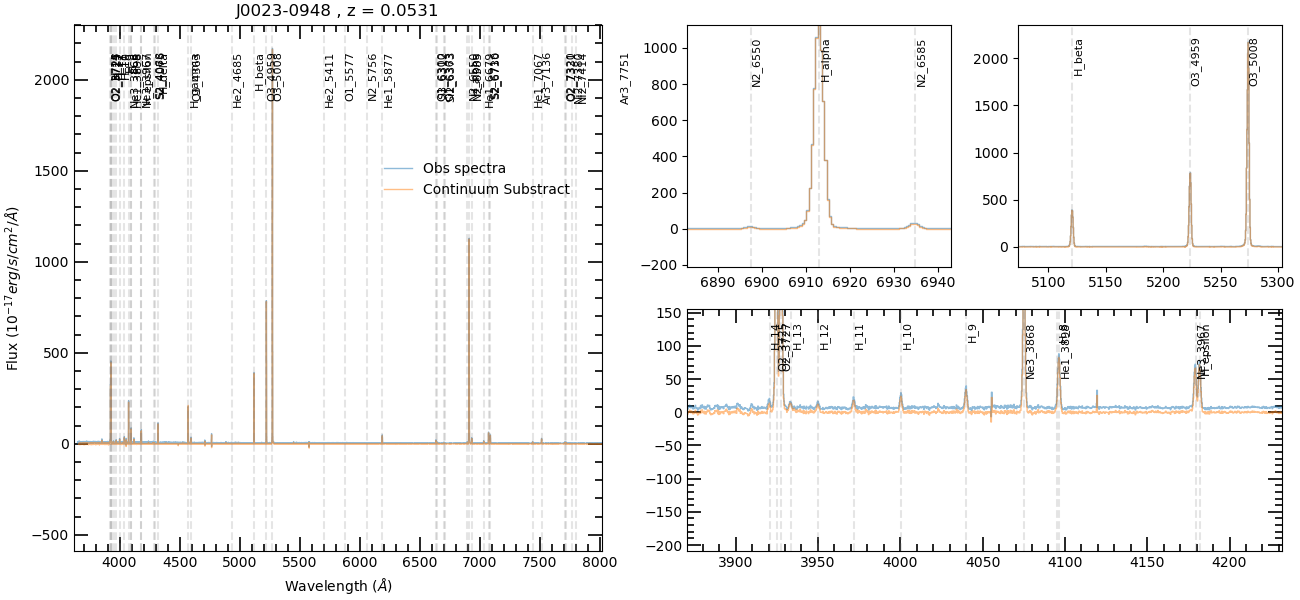

Saved continuum substracted data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/cont_subs/J0023/cont_corr_J0023.csv


In [7]:
CONTINUUM_SUBSTRACT(J0023)

Reading data for J0023
Using uncorrected data


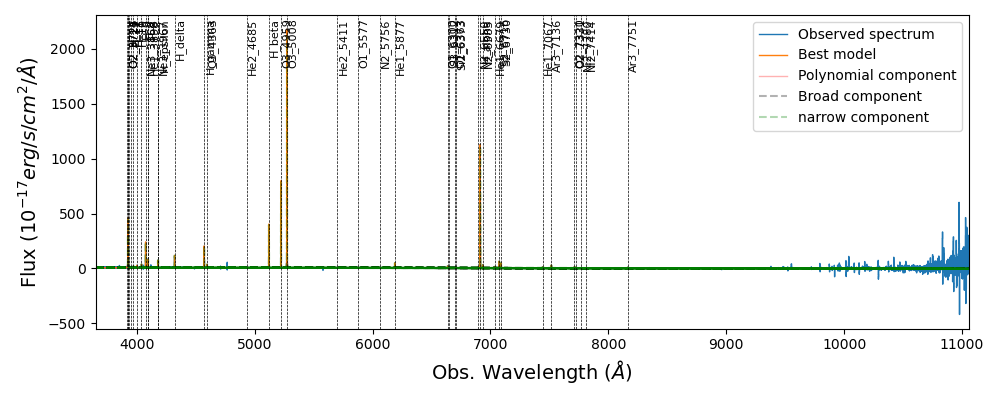

In [102]:
red = REDUC_LINES(J0023)
fit = red.fit_spectra(show_Plot=True)

In [103]:
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['H_alpha']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['H_beta']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['O3_5008']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['O3_4363']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['N2_6550']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['N2_6585']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))

1.4078887525584576
1.042888738986879
1.0741044767697812
0.9360303305339007
1.4047315620102112
1.4123257507169746


In [8]:
red.fit_MC(numMC=100)

Calculating the first initial params
Starting MC iteration
Executed fit_MC in 1263.9104s


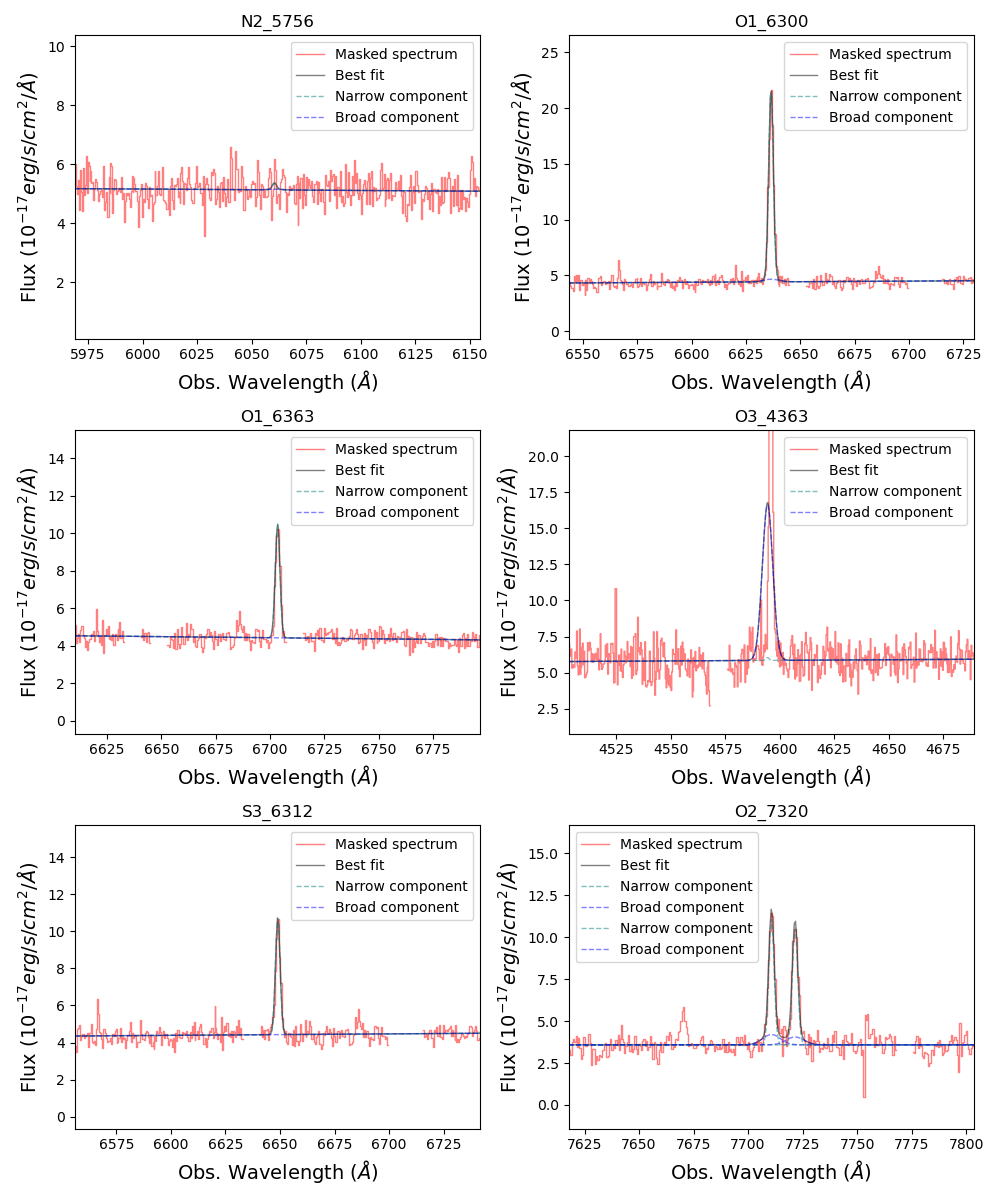

,sigma_v_narrow,sigma_v_broad,N2_5756_narrow_amplitude,N2_5756_broad_amplitude,O1_6300_narrow_amplitude,O1_6300_broad_amplitude,O1_6363_narrow_amplitude,O1_6363_broad_amplitude,O3_4363_narrow_amplitude,O3_4363_broad_amplitude,S3_6312_narrow_amplitude,S3_6312_broad_amplitude,O2_7320_narrow_amplitude,O2_7320_broad_amplitude,O2_7331_narrow_amplitude,O2_7331_broad_amplitude
0,47.9173,157.459929,0.522372,0.208561,45.732325,2.07004,16.270501,1.205228e-07,0.358742,65.010722,16.854489,6.777271e-09,23.16584,6.248263,21.688638,4.775596


In [5]:
red.fit_auroral(red.wave, red.flux, showplot=True)

In [6]:
df = red.fit_MC_auroral(numMC=100)

/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/lines.py:381: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  info = pd.concat([info, df], ignore_index=True)


Executed fit_MC_auroral in 22.5903s


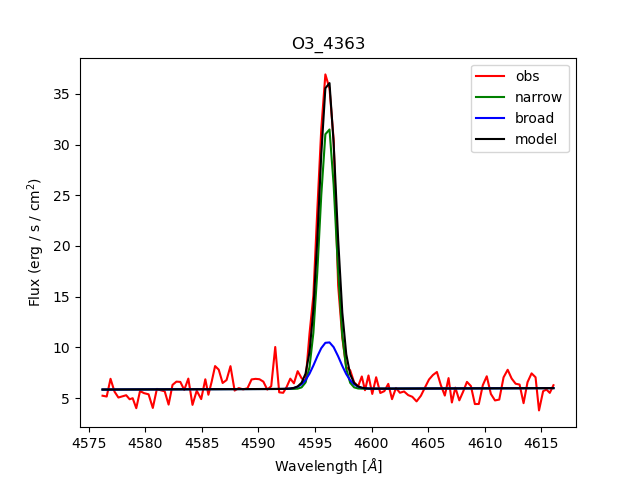

In [77]:
from astropy.io import fits
from lmfit.models import GaussianModel, PolynomialModel
from lmfit.parameter import Parameter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# get data
save_path = '/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/J0023.fits'
dcorr = fits.open(save_path)[1].data
wave, flux, sigma = dcorr['wave'], dcorr['flux'], dcorr['sigma']

# stamp
label = 'O3_4363'
class_ = J0023
wave_rest = class_.linelist_dict[label]
wave_obs = wave_rest * (1 + class_.redshift)
mask = ((wave > wave_obs - 20) & (wave < wave_obs + 20))
wave_stamp, flux_stamp = wave[mask], flux[mask]
sigma_stamp = dcorr['sigma'][mask]

# model
narrow_gaussian = GaussianModel(prefix=label+'_narrow_')
broad_gaussian = GaussianModel(prefix=label+'_broad_')

# Create a polynomial model for the continuum
polydeg = 7
polynomial = PolynomialModel(degree=polydeg)

sum_of_gaussians = narrow_gaussian + broad_gaussian

comp_mult = sum_of_gaussians + polynomial
pars_mult = comp_mult.make_params()

pars_mult.add(name='z', value=class_.redshift, vary=False)

pars_mult.add(name='sigma_v_narrow', value=30, min=20, max=50)
pars_mult.add(name='sigma_v_broad', value=60, min=50, max=70)

for param in ['center', 'amplitude', 'sigma']:
    narrow_key = f'{label}_narrow_{param}'
    if param == 'center':
        value = wave_rest
        vary = False
        expr = f'{wave_rest:6.2f}*(1+z)'
    elif param == 'amplitude':
        value = 1
        vary = True
        expr = None
    elif param == 'sigma':
        vary = True
        expr = f'(sigma_v_narrow/3e5)*{label}_narrow_center'
    pars_mult[narrow_key] = Parameter(name=narrow_key, value=value,
                                        vary=vary, expr=expr,
                                        min=0.0)


for param in ['center', 'amplitude', 'sigma']:
    broad_key = f'{label}_broad_{param}'
    if param == 'center':
        value = wave_rest
        vary = False
        expr = f'{wave_rest:6.2f}*(1+z)'
    elif param == 'amplitude':
        value = 0.3
        vary = True
        expr = None
    elif param == 'sigma':
        vary = True
        expr = f'(sigma_v_broad/3e5)*{label}_broad_center'
    pars_mult[broad_key] = Parameter(name=broad_key,
                                        value=value, min=0.0,
                                        vary=vary, expr=expr)

for i in range(polydeg+1):
    pars_mult[f'c{i:1.0f}'].set(value=0)

comps = []
for i in range(100):
    y_off = flux_stamp + np.random.randn(len(flux_stamp)) * sigma_stamp
    out_comp_mult = comp_mult.fit(y_off, pars_mult, x=wave_stamp,
                                    nan_policy='omit', max_nfev=1000)
    comps.append(out_comp_mult)

# plot 1
model = comps[0].eval_components(x=wave_stamp)
plt.figure()
plt.plot(wave_stamp, flux_stamp, color='red', label='obs')
plt.plot(wave_stamp, model[f'{label}_narrow_'] + model['polynomial'], color='green', label='narrow')
plt.plot(wave_stamp, model[f'{label}_broad_'] + model['polynomial'], color='blue', label='broad')
plt.plot(wave_stamp, comps[0].best_fit, color='black', label='model')
plt.title(label)
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r'Flux (erg / s / cm$^{2}$)')
plt.title(label)
plt.legend()
plt.show()

# Saving
sum_narr = []
sum_bro = []
sum = []
for comp in comps:
    sum_narr.append(comp.params[f'{label}_narrow_amplitude'].value)
    sum_bro.append(comp.params[f'{label}_broad_amplitude'].value)
    sum.append(comp.params[f'{label}_narrow_amplitude'].value + comp.params[f'{label}_broad_amplitude'].value)
median_narr = np.median(sum_narr)
std_narr = np.std(sum_narr)

median_bro = np.median(sum_bro)
std_bro = np.std(sum_bro)

median = np.median(sum)
std = np.std(sum)
df = pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/J0023/J0023_auroral_model.csv')
df

In [ ]:
df.loc[2, 'flux'] = median
df.loc[2, 'fluxerr'] = std
df.loc[2, 'narrow_flux'] = median_narr
df.loc[2, 'narrow_fluxerr'] = std_narr
df.loc[2, 'broad_flux'] = median_bro
df.loc[2, 'broad_fluxerr'] = std_bro
df

In [99]:
df.to_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/J0023/J0023_auroral_model.csv')

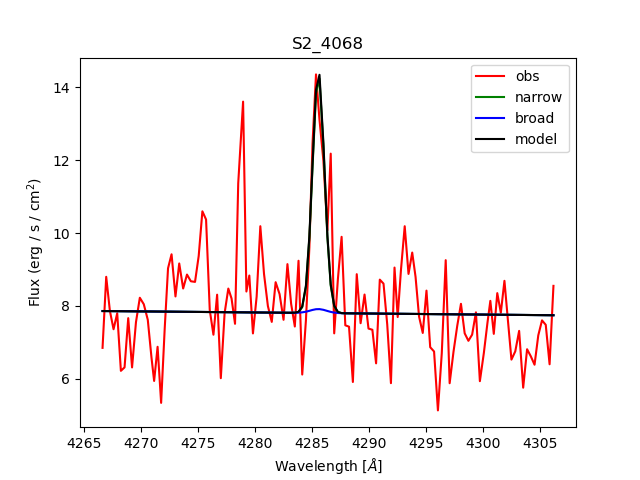

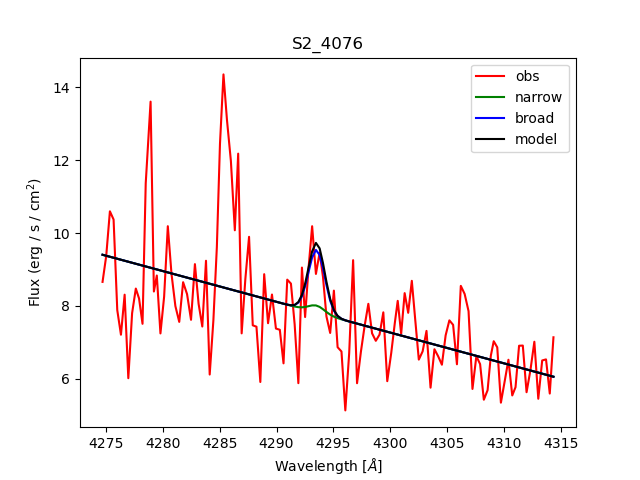

In [4]:
from astropy.io import fits
from lmfit.models import GaussianModel, PolynomialModel
from lmfit.parameter import Parameter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# get data
save_path = '/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/J0023.fits'
dcorr = fits.open(save_path)[1].data
wave, flux, sigma = dcorr['wave'], dcorr['flux'], dcorr['sigma']

# stamp
labels = 'S2_4068', 'S2_4076'
class_ = J0023
name= 'J0023'
df = pd.read_csv(f'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/{name}/{name}_auroral_model.csv')
for label in labels:
    wave_rest = class_.linelist_dict[label]
    wave_obs = wave_rest * (1 + class_.redshift)
    mask = ((wave > wave_obs - 20) & (wave < wave_obs + 20))
    wave_stamp, flux_stamp = wave[mask], flux[mask]
    sigma_stamp = dcorr['sigma'][mask]

    # model
    narrow_gaussian = GaussianModel(prefix=label+'_narrow_')
    broad_gaussian = GaussianModel(prefix=label+'_broad_')

    # Create a polynomial model for the continuum
    polydeg = 1
    polynomial = PolynomialModel(degree=polydeg)

    sum_of_gaussians = narrow_gaussian + broad_gaussian

    comp_mult = sum_of_gaussians + polynomial
    pars_mult = comp_mult.make_params()

    pars_mult.add(name='z', value=class_.redshift, vary=True)

    pars_mult.add(name='sigma_v_narrow', value=30, min=20, max=50)
    pars_mult.add(name='sigma_v_broad', value=60, min=50, max=70)

    for param in ['center', 'amplitude', 'sigma']:
        narrow_key = f'{label}_narrow_{param}'
        if param == 'center':
            value = wave_rest
            vary = True
            expr = f'{wave_rest:6.2f}*(1+z)'
        elif param == 'amplitude':
            value = 1
            vary = True
            expr = None
        elif param == 'sigma':
            vary = True
            expr = f'(sigma_v_narrow/3e5)*{label}_narrow_center'
        pars_mult[narrow_key] = Parameter(name=narrow_key, value=value,
                                            vary=vary, expr=expr,
                                            min=0.0)


    for param in ['center', 'amplitude', 'sigma']:
        broad_key = f'{label}_broad_{param}'
        if param == 'center':
            value = wave_rest
            vary = False
            expr = f'{wave_rest:6.2f}*(1+z)'
        elif param == 'amplitude':
            value = 0.3
            vary = True
            expr = None
        elif param == 'sigma':
            vary = True
            expr = f'(sigma_v_broad/3e5)*{label}_broad_center'
        pars_mult[broad_key] = Parameter(name=broad_key,
                                            value=value, min=0.0,
                                            vary=vary, expr=expr)

    for i in range(polydeg+1):
        pars_mult[f'c{i:1.0f}'].set(value=0)

    comps = []
    for i in range(100):
        y_off = flux_stamp + np.random.randn(len(flux_stamp)) * sigma_stamp
        out_comp_mult = comp_mult.fit(y_off, pars_mult, x=wave_stamp,
                                        nan_policy='omit', max_nfev=1000)
        comps.append(out_comp_mult)

    # plot 1
    model = comps[0].eval_components(x=wave_stamp)
    plt.figure()
    plt.plot(wave_stamp, flux_stamp, color='red', label='obs')
    plt.plot(wave_stamp, model[f'{label}_narrow_'] + model['polynomial'], color='green', label='narrow')
    plt.plot(wave_stamp, model[f'{label}_broad_'] + model['polynomial'], color='blue', label='broad')
    plt.plot(wave_stamp, comps[0].best_fit, color='black', label='model')
    plt.title(label)
    plt.xlabel(r"Wavelength [$\AA$]")
    plt.ylabel(r'Flux (erg / s / cm$^{2}$)')
    plt.title(label)
    plt.legend()
    plt.show()

    # Saving
    sum_narr = []
    sum_bro = []
    sum = []
    for comp in comps:
        sum_narr.append(comp.params[f'{label}_narrow_amplitude'].value)
        sum_bro.append(comp.params[f'{label}_broad_amplitude'].value)
        sum.append(comp.params[f'{label}_narrow_amplitude'].value + comp.params[f'{label}_broad_amplitude'].value)
    median_narr = np.median(sum_narr)
    std_narr = np.std(sum_narr)

    median_bro = np.median(sum_bro)
    std_bro = np.std(sum_bro)

    median = np.median(sum)
    std = np.std(sum)

    new_row ={
        'ID':df['ID'][0],
        'mass': df['mass'][0],
        'z':df['z'][0],
        'name':label,
        'flux':median,
        'fluxerr':std,
        'narrow_flux':median_narr,
        'narrow_fluxerr':std_narr,
        'broad_flux':median_bro,
        'broad_fluxerr':std_bro
    }
    df.loc[len(df)] = new_row
df.to_csv(f'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/{name}/{name}_auroral_model.csv')